## Spotify Exploratory Data Analysis: How to Make a Hit

### Project Overview
Can the success of a song be engineered? In this personal project, I explore a dataset of over 114,000 Spotify tracks to determine if specific audio features, such as rhythm, energy, or vocal content, can strategically predict a song's popularity.

By analyzing the various audio features provided by this Spotify dataset, my goal is to see if there is a statistical "recipe" for success or if the secret to a hit lies in outside factors.

### Methods
The analysis follows a standard data science workflow:
1. **Data Cleaning:** Handling missing values and removing duplicate tracks (such as "deluxe" or "remastered" versions) to ensure a representative sample.
2. **Exploratory Data Analysis (EDA):** Identifying correlations between popularity and features.
3. **Visualization:** Using distributions, heatmaps, and box plots to answer specific research questions.

### Research Questions
1. What audio features have the biggest association with a song's popularity?
2. Do instrumental tracks differ in popularity from vocal tracks?
3. Do explicit songs perform better than non-explicit songs?
4. Do songs with different genres differ in popularity?
5. What does the distribution of song popularity look like on Spotify, and what does this imply for analysis?
6. Has song length or other features changed over time?

(All of my data is sourced from Kaggle: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset?resource=download)

### Setup and Imports!

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**Load the data**

In [23]:
df = pd.read_csv("data/spotify_dataset.csv", index_col=0) #index_col=0 gets rid of the Unnamed column in the dataset
df.head()


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


**Explore the dataset**

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

**Basic Statistics**

In [25]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Just from these basic statistics, it looks like most songs aren't very popular, with a mean of about 33 out of 100. That was probably the only surprising statistic. Other things to note are that songs average a duration of about 3.8 minutes, dancability seems to be very normally distributed, and most songs have very little "speechiness." It's also worth noting that features like Key and Mode are categorical features, represented by numeric values.

## Data Cleaning
We'll start  by looking at the missing values to determine whether they are random to decide if we can drop them.

In [26]:
df.isna().sum().sort_values(ascending=False) #This gets the sum of null values in each colum in our dataframe

df = df.dropna()

It looks like there are only three null values in the entire dataset, and they have to do with the song name, album name, and artist. Sense these are insignificant, we can drop them.

Next, let's check for duplicate values

In [27]:
df.duplicated().sum()

np.int64(450)

There were 450 duplicates.

**Duplicate Removal**
Now, let's get clean the duplicate values to avoid bias towards frequently re-uploaded songs.

In [28]:
df = df.drop_duplicates(subset=['track_name', 'artists']) #Removes songs that have the same name and artist, so the same song on a different album, such as a top hit's album or deluxe version, aren't counted and don't bias the analysis.

**Column Ranges**

In [29]:
df[['danceability','energy','speechiness','acousticness','valence']].describe() #Check

audio_features = [ #Features that should be between 0 - 1.
    'danceability','energy','speechiness',
    'acousticness','valence'
]

for col in audio_features: #loop through and remove rows where values are out of range
    df = df[(df[col] >= 0) & (df[col] <= 1)]

#popularity
df = df[(df['popularity'] >= 0) & (df['popularity'] <= 100)]


This enforces the range of values for each feature, removing invalid rows.

**Fix Data Types:**

In [30]:
df.dtypes #See types. They all look good



track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

**Final check**

In [31]:
print("Final shape:", df.shape)
df.describe()


Final shape: (81343, 20)


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,81343.000000,8.134300e+04,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000
mean,34.636392,2.314145e+05,0.559276,0.635025,5.285900,-8.593930,0.632347,0.088993,0.329666,0.184733,0.219723,0.463277,122.144834,3.896967
std,19.438517,1.164924e+05,0.177747,0.258641,3.557629,5.304797,0.482169,0.116629,0.339961,0.331592,0.198272,0.263383,30.129012,0.456398
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,1.738710e+05,0.446000,0.455000,2.000000,-10.451500,0.000000,0.036100,0.015900,0.000000,0.098500,0.241000,99.408000,4.000000
50%,35.000000,2.152050e+05,0.573000,0.678000,5.000000,-7.262000,1.000000,0.049100,0.190000,0.000089,0.133000,0.449000,122.030000,4.000000
75%,49.000000,2.673460e+05,0.690000,0.857000,8.000000,-5.140000,1.000000,0.087000,0.629000,0.153000,0.283000,0.676000,140.128500,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


After cleaning, the dataset contains 81,344 songs with 20 features. I removed rows with incomplete features, removed duplicate tracks, validated feature ranges, and ensured correct data types. The final dataset is ready for analysis!

## Analysis

###  Question 1: What audio features have the biggest association with a song's popularity?
I'll make a correlation heatmap to visualize the relation between popularity and audio features. I'm using a heatmap because it lets you compare many different audio features at once.

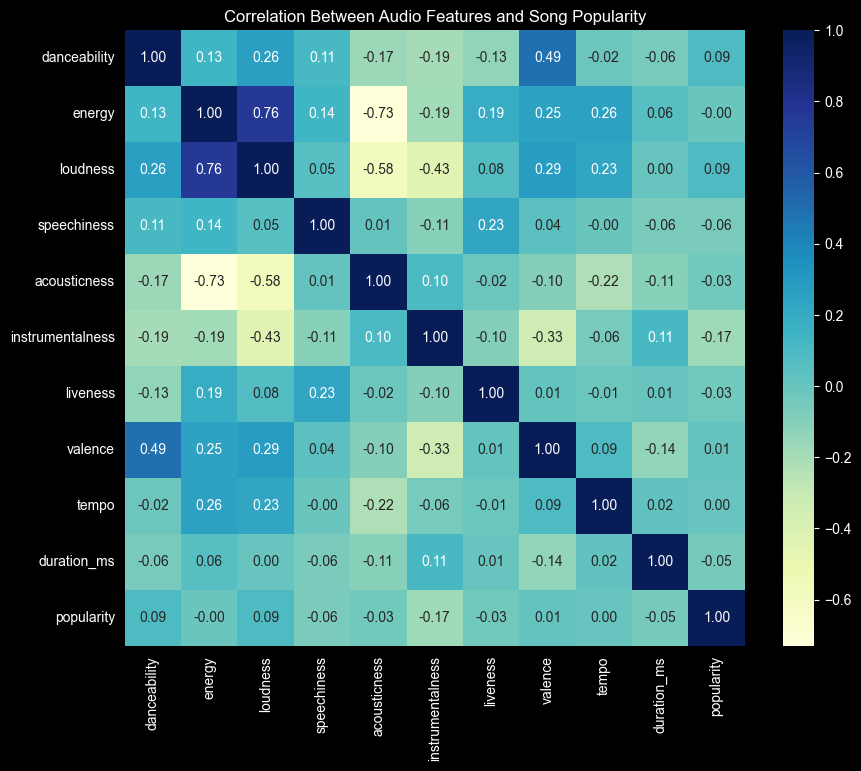

In [32]:
#Define the scope of my analysis
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms', 'popularity'
]

df_audio = df[audio_features]

#Get correlations
corr_matrix = df_audio.corr()

#Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Correlation Between Audio Features and Song Popularity")
plt.show()



**Interpretation:** Looking at the heatmap, the two audio features with the closest correlation to popularity are dancability and loudness. Although they have the greatest correlation, except for instrumentalness, they still have a weak relationship. This means that as loudness and dancability increase, popularity tends to slightly increase as well.

Instrumentalness, on the other hand, has a stronger correlation than any other feature. Its correlation is -0.17, meaning that as a song's instrumentalness increases, the song's popularity tends to decrease. It's still weak, but noticeably stronger!

**Conclusion**: The correlations between a song's features and its popularity are small, so I can conclude that audio features are not a good predictor for popularity.

**Follow-up** plot to demonstrate the relationship between instrumentalness and popularity. As you can see, this plot shows a nonlinear relationship.

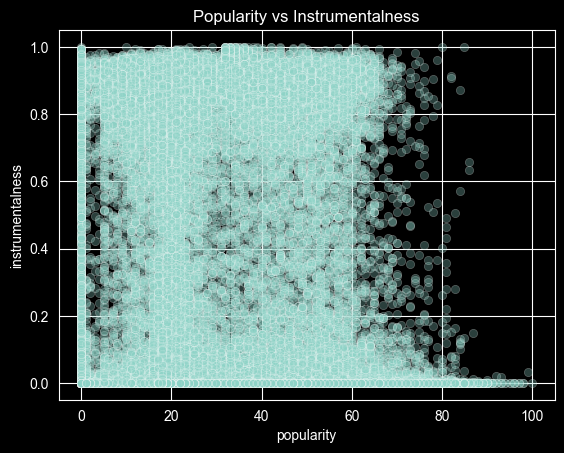

In [33]:
sns.scatterplot(
    data=df,
    y='instrumentalness',
    x='popularity',
    alpha=0.3
)

plt.title("Popularity vs Instrumentalness")
plt.show()


Loudness shows a very weak negative correlation with popularity, as seen in this plot. This shows that instrumental tracks tend to be less popular, but it's still not a good indicator of popularity.

### Question 2: Do instrumental tracks differ in popularity from vocal tracks?

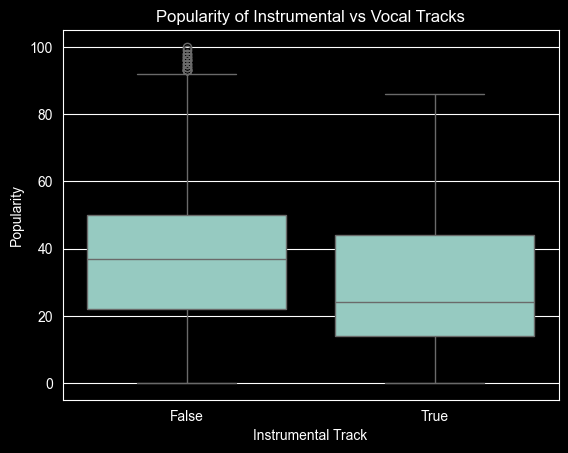

In [34]:
#instrumentalness > 0.5 means the song is mostly instrumental
df['is_instrumental'] = df['instrumentalness'] > 0.5

#Compare popularity
df.groupby('is_instrumental')['popularity'].mean()

#Plot!
sns.boxplot(
    data=df,
    x='is_instrumental',
    y='popularity'
)

plt.xlabel("Instrumental Track")
plt.ylabel("Popularity")
plt.title("Popularity of Instrumental vs Vocal Tracks")
plt.show()



**Interpretation**: It looks like instrumental tracks tend to have lower average popularity than vocal tracks, which supports our earlier results.

**Conclusion:** Our plot tells us that vocal songs on Spotify tend to be more popular than instrumental songs.

### Question 3: Do explicit songs perform better than non-explicit songs?
To answer this, we'll create a boxplot to compare the popularity of explicit and non-explicit songs.

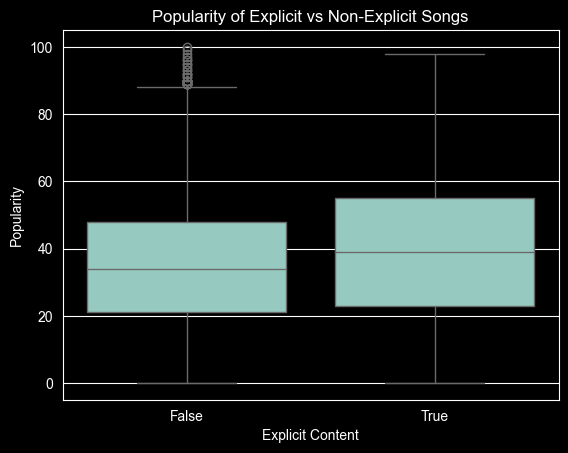

In [35]:
#Compare popularity:
df.groupby('explicit')['popularity'].mean()

#Plot!
sns.boxplot(
    data=df,
    x='explicit',
    y='popularity'
)

plt.xlabel("Explicit Content")
plt.ylabel("Popularity")
plt.title("Popularity of Explicit vs Non-Explicit Songs")
plt.show()

**Interpretation:** Looking at the plot, it's clear that explicit tracks tend to perform better than non-explicit tracks. Explicit tracks have a higher average popularity, which I find interesting! I think if we made this same plot 20 or 40 years ago, it would look a lot different! I also wonder if it will change in the future. This is something I want to test, but there are no enough time variables in our dataset.

**Conclusion:** Explicit songs tend to perform better than non-explicit songs.



### Question 4: Do songs with different genres differ in popularity?

To start analzying how different genres might have a relationship with a song's popularity, let's find the top 10 most popular genres. We'll do this by grouping each song by track_genre and by calculating the average popoularity for each. We'll visualize this with a bar chart so we are able to clearly see the differences.

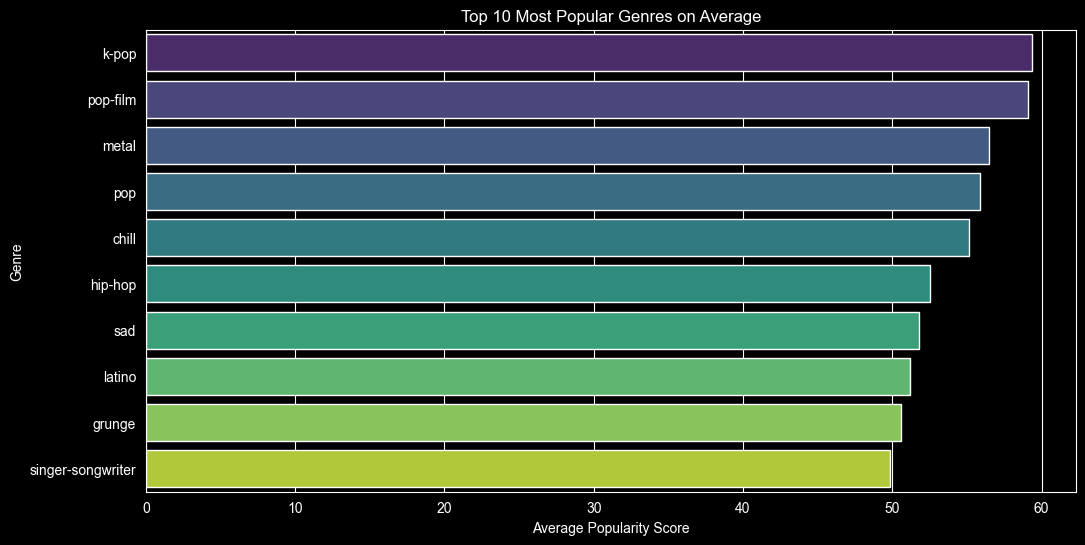

track_genre
k-pop                59.334895
pop-film             59.122525
metal                56.450704
pop                  55.906355
chill                55.145055
hip-hop              52.525038
sad                  51.807836
latino               51.174699
grunge               50.563172
singer-songwriter    49.831019
Name: popularity, dtype: float64


In [36]:
# Group by genre and calculate the mean popularity
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

# Get the top 10 genres
top_10_genres = genre_popularity.head(10)

# Visualize the results
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_genres.values,
    y=top_10_genres.index,
    hue=top_10_genres.index,  # Fix: Assign y to hue and set legend=False to remove the warning
    palette='viridis',
    legend=False
)
plt.title('Top 10 Most Popular Genres on Average')
plt.title('Top 10 Most Popular Genres on Average')
plt.xlabel('Average Popularity Score')
plt.ylabel('Genre')
plt.show()

print(top_10_genres)

**Interpretation**: It looks like the top two most popular genres on average are k-pop and pop-film with an average popularity score ~59! It was surprising to see that metal was the third most popular. I can only assume that means that metal fans are extremely loyal!

Now, we know which genres are the most popular on average, but let's find out _why_. Let's compare each of these genres' audio features to see if any of them are similar to other popular genres. Let's start analyzing this by finding each of the songs belonging to our top 10 most popular genres and calculating their average audio features. We can visualize this nicely with a heatmap, which compares multiple features across multiple categories at once.

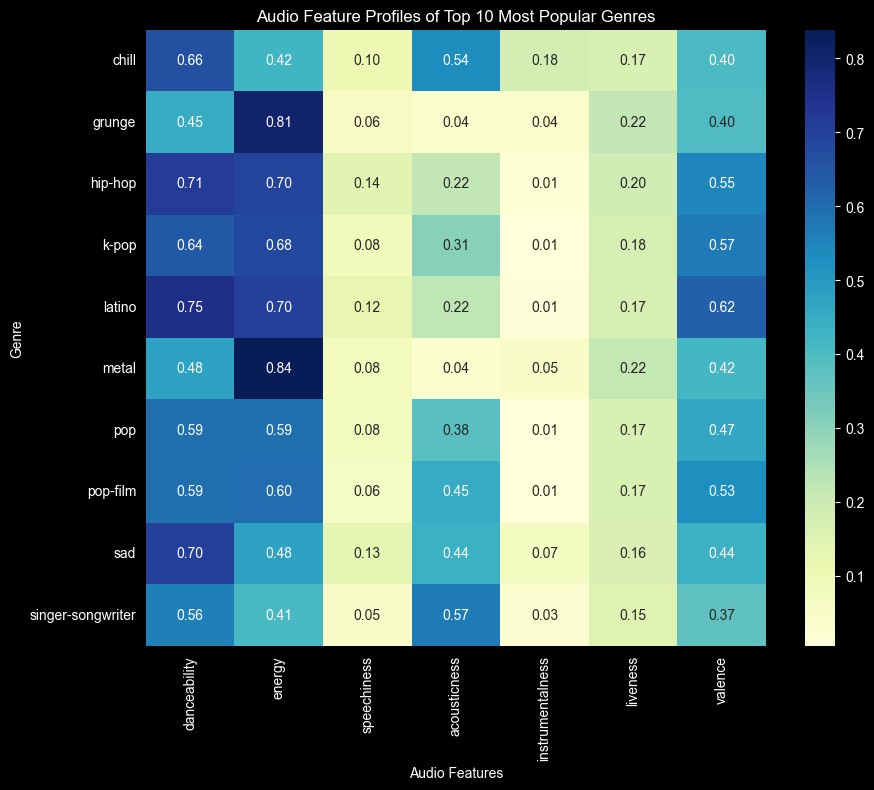

In [37]:
# 1. Define the features we want to compare
features = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']

# 2. Filter the main dataframe to only include the top 10 genres
top_10_df = df[df['track_genre'].isin(top_10_genres.index)]

# 3. Group by genre and calculate the mean for these features
genre_features = top_10_df.groupby('track_genre')[features].mean()

# 4. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(genre_features, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Audio Feature Profiles of Top 10 Most Popular Genres')
plt.xlabel('Audio Features')
plt.ylabel('Genre')
plt.show()

**Interpretation**: Immediately, a few columns in our heatmap stood out: dancability, energy, speechiness, and instrumentalness. If you look at the vertical columns in each of these features, you'll notice all the popular genres tend to stick to the trend. With dancability, it looks like most of the top 10 most popular genres are very danceable! The energy feature seems to have a similar profile. While popularity is diverse, 7 out of the top 10 genres shared an energy score above ~0.60, suggesting a strong correlation between rhythm and mainstream appeal. On the other hand, the one that stood out most was instrumentalness. It looks like each of these genres scores extremely low on insturmentalness, meaning that almost not popular songs are highly instrumental. This makes sense compared to our previous findings.

Possible revision of interpretation, (By Jack): The heatmap reveals a consistent "audio DNA" shared by the most popular genres. Danceability and Energy are the most prominent traits, with 7 out of the top 10 genres scoring above 0.60, suggesting a strong correlation between high-energy rhythms and mainstream appeal. Conversely, Instrumentalness shows the most striking trend: it is near zero across all top genres. This indicates that mainstream popularity is almost exclusively reserved for vocal-heavy tracks. Additionally, the consistently low Acousticness (with the exception of the 'Chill' and 'Singer-Songwriter' genres) suggests that synthesized or electric production dominates the top of the charts

**Conclusion:**
After analyzing the top 10 most popular genres, a clear mainstream audio profile emerged. While the top 10 genres, such as K-pop and metal, are very diverse and differently sounding to the human ear, they share a consistent "audio DNA":
1. High energy and dancability are a non-negotiable feature for popularity. With 7 of the 10 genres sharing an energy score above ~0.60, this confirms that the most successful track on spotify tends to have upbeat rhythm and high intensity.
2. Vocals are essential. The most striking similarity across genres was that they all shared a near-0 insturmentalness score. This suggests that for a song to become mainstream, vocals are basically a requirement. Purely instrumental tracks will struggle to reach the same average level of popularity.
3. Melodies take priority over spoken words. With each genre having a consistently low speechiness score, this indicates that mainstream appeal is driven by melody rather than spoken-word.

### Question 5: What does the distribution of song popularity look like on Spotify, and what does this imply for analysis?
First, let's see if popularity is evenly spread, or skewed.

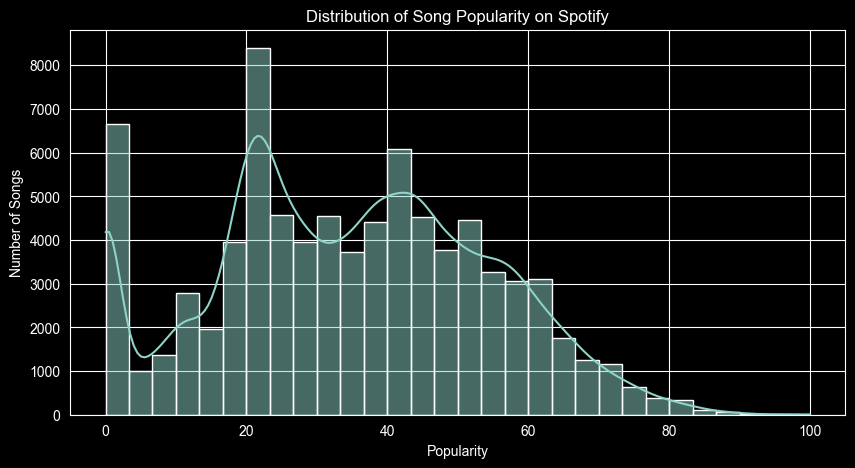

In [38]:

plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=30, kde=True)

plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.title("Distribution of Song Popularity on Spotify")
plt.show()



**Interpretation:** Looking at the plot, we can see that it is right-skewed, meaning our dataset has many songs with low popularity and very few songs with high popularity. This explains the weak correlations between audio features and popularity and tells us that "average popularity" is misleading.

Let's quantify it:

In [39]:
df['popularity'].describe()


count    81343.000000
mean        34.636392
std         19.438517
min          0.000000
25%         21.000000
50%         35.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64

**Conclusion**: Looking at the distribution and statistics for popularity in our dataset, we can see that popularity is highly skewed, with most tracks having a low popularity and a tiny number of tracks having high popularity. This helps us explain why there was such a weak correlation between a songs audio features and its popularity, which leads us to assume that a song's popularity is mainly influenced by other outside factors.

### Question 6: Has song length or other features changed over time?
As stated before, unfortunately, the data set does not include a variable that tracks the time a song was released, so we can't accurately answer this question.

## Conclusion and Key Takeaways:
I hope you enjoyed this analysis! I hope you learned something new about Spotify data and how to use it to make better predictions about music! I hope these insights could help independent artists or labels to optimize their production to increase their chances of creating a hit. Here are some key takeaways from my analysis:
1. Loudness and Dancability show the strongest positive relationship with a songs' popularity; however, they aren't good predictors of whether a song will be popular.
2. Acoustic features such as instrumentalness and acousticness are less associated with high popularity.
3. Explicit songs tend to perform better than non-explicit songs.
4. Looking at the audio profiles for the top performing genres, dancability and energy seem to be the common feature between the genres.